In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar
from scipy.integrate import quad

In [ ]:
# Constants in natural units

G = 6.708e-39  # Newton's Gravitational constant
M_pl = 1.22e19  # Planck mass
M_sun = 1.116e57  # Mass of the sun
pi = np.pi

In [ ]:
# Toy potential parameters from Hong et al

w0_default = 400.0   # true vacuum vev at T = 0
M_phi_default = 100.0  # true vacuum scalar mass
c_th_default = 0.4  # thermal mass coefficient

In [ ]:
# Toy Potential Pipeline

def toy_potential(phi, T, w0, M_phi, c_th, mu3):
  mu2 = -0.5 * (M_phi**2 + mu3 * w0)
  lam = 0.5 / w0 * (M_phi**2 / w0 - mu3)
  return 0.5 * (mu2 + c_th * T**2) * phi**2 + (mu3 / 3.0) * phi**3 + 0.25 * lam * phi**4


# Minima-finding function

def find_minima(T, w0, M_phi, c_th, mu3, phi_min=-800.0, phi_max=800.0):
  n_windows = 80
  xs = np.linspace(phi_min, phi_max, n_windows + 1)
  minima = []

  for i in range(n_windows):
      a, b = xs[i], xs[i + 1]
      res = minimize_scalar(lambda p: toy_potential(p, T, w0, M_phi, c_th, mu3), bounds=(a, b), method="bounded")
      if not res.success:
          continue

      phi_star = res.x
      V_star = toy_potential(phi_star, T, w0, M_phi, c_th, mu3)

      # second derivative test via finite differences
      h = 1e-2 * max(1.0, abs(phi_star))
      Vpp = (toy_potential(phi_star + h, T, w0, M_phi, c_th, mu3) - 2.0 * toy_potential(phi_star, T, w0, M_phi, c_th, mu3) + toy_potential(phi_star - h, T, w0, M_phi, c_th, mu3)) / h**2

      if Vpp > 0:
        minima.append((phi_star, V_star))

  # Deduplicate minima close in φ
  minima_sorted = sorted(minima, key=lambda x: x[0])
  uniq = []
  tol = 1e-2
  for p, V in minima_sorted:
      if not uniq or abs(p - uniq[-1][0]) > tol:
          uniq.append((p, V))

  return uniq


# Critical temperature-finding function

def find_critical_temperature_scan(mu3, w0=w0_default, M_phi=M_phi_default, c_th=c_th_default, T_low=10.0, T_high=500.0, n_T=1000):
  T_vals = np.linspace(T_low, T_high, n_T)

  best_Tc = None
  best_deltaV_abs = np.inf
  best_phi_true = None
  best_V_false = None
  best_V_true = None

  for T in T_vals:
    V_false = toy_potential(0.0, T, w0, M_phi, c_th, mu3)
    mins = find_minima(T, w0, M_phi, c_th, mu3)
    if not mins:
      continue

    eps = 1e-2
    nonzero_mins = [(phi, V) for (phi, V) in mins if abs(phi) > eps]
    if not nonzero_mins:
      continue

    phi_true, V_true = sorted(nonzero_mins, key=lambda x: x[1])[0]
    deltaV = V_false - V_true

    if abs(deltaV) < best_deltaV_abs:
      best_deltaV_abs = abs(deltaV)
      best_Tc = T
      best_phi_true = phi_true
      best_V_false = V_false
      best_V_true = V_true

  if best_Tc is None:
    raise RuntimeError(f"Could not find Tc for mu3={mu3:.2f}.")

  phi_false = 0.0
  V_false = best_V_false
  phi_true = best_phi_true
  V_true = best_V_true

  return best_Tc, phi_false, phi_true, V_false, V_true

In [ ]:
# Simulation Pipeline

class Simulator:
  def __init__(self, T_c, v, y=1.0, eta=1e-10):
    self.T_c = T_c   # critical temp from toy potential pipeline
    self.v = v   # true vacuum vev from toy potential pipeline
    self.y = y   # yukawa coupling
    self.eta = eta   # fermion-antifermion asymmetry
    self.m_fermion = y * v   # true vacuum fermion mass

  def nucleation_temperature(self):
    return 0.9 * self.T_c

  def fermi_ball_number_density(self, T_star, v_b=0.6, S3_T=140.0):
    Gamma = T_star**4 * np.exp(-S3_T)
    p_T = 0.29
    return (3.0 / (4.0 * pi))**0.25 * (Gamma / v_b)**0.75 * p_T

  def F_trap(self, T_star, v_b=0.6):
    M_star = self.y * self.v
    return 1.0 - np.exp(-(M_star / T_star) / 2.0) * (1.0 - v_b)

  def fermi_ball_charge(self, T_star, n_FB_star):
    g_star = 100.0   # relativistic degrees of freedom
    s_star = (2.0 * pi**2 / 45.0) * g_star * T_star**3

    F = self.F_trap(T_star)
    n_excess = self.eta * s_star
    n_trapped = F * n_excess
    return n_trapped / n_FB_star

  def fermi_ball_mass_radius(self, Q_FB, T_star, U_0=None):
    if U_0 is None or U_0 <= 0.0:
      U_0 = (0.25 * self.T_c)**4

    M_FB = Q_FB * (12.0 * pi**2 * U_0)**0.25
    R_FB = (Q_FB)**(1.0/3.0) * ((3.0/16.0) * (3.0/(2.0*pi))**(2.0/3.0) * (1.0/U_0))**0.25
    return M_FB, R_FB

  def yukawa_collapse_temperature(self, R_FB, Q_FB):
    mean_sep = R_FB / (Q_FB)**(1.0/3.0)   # mean fermion separation
    c = 0.4
    return mean_sep / np.sqrt(c)

  def pbh_mass(self, M_FB, R_FB):
    return 0.8 * M_FB

  def pbh_abundance(self, M_PBH, n_FB_star):
    return n_FB_star * M_PBH

  def dark_matter_fraction(self, M_PBH, beta, T_star, v_b=0.6):
    g_star = 100.0
    rho_rad = (pi**2 / 30.0) * g_star * T_star**4
    H = np.sqrt((8.0 * pi) / (3.0 * M_pl**2) * rho_rad)

    return (1.3e3 * v_b**(-3.0) * (g_star / 100.0)**0.5 * (T_star / 100.0)**3 * ((beta / H) / 100.0)**3 * (M_PBH / 1e15))

In [ ]:
# Best Configuation Pipeline

def run_simulation(mu3_list, y_list, eta_fixed, w0=w0_default, M_phi=M_phi_default, c_th=c_th_default):
  results = {"mu3": [], "y": [], "M_PBH": [], "f_PBH": [], "M_FB": [], "R_FB": [], "T_c": []}

  for mu3 in mu3_list:
    T_c, phi_false, phi_true, V_false, V_true = find_critical_temperature_scan(mu3, w0=w0, M_phi=M_phi, c_th=c_th)
    dV = V_false - V_true
    U0 = abs(dV)
    if U0 <= 0.0:
      U0 = (0.1 * T_c)**4
    v_true = phi_true

    for y in y_list:
      sim = Simulator(T_c=T_c, v=v_true, y=y, eta=eta_fixed)

      T_star = sim.nucleation_temperature()
      n_FB = sim.fermi_ball_number_density(T_star)

      Q_FB = sim.fermi_ball_charge(T_star, n_FB)
      M_FB, R_FB = sim.fermi_ball_mass_radius(Q_FB, T_star, U_0=U0)

      M_PBH = sim.pbh_mass(M_FB, R_FB)
      beta = sim.pbh_abundance(M_PBH, n_FB)
      f = sim.dark_matter_fraction(M_PBH, beta, T_star)

      results["mu3"].append(mu3)
      results["y"].append(y)
      results["M_PBH"].append(M_PBH / M_sun)
      results["f_PBH"].append(f)
      results["M_FB"].append(M_FB)
      results["R_FB"].append(R_FB)
      results["T_c"].append(T_c)

  return results

def extract_best_configuration(results, target_logM=-13.8, target_f=1.0):
  mu3 = np.array(results["mu3"])
  y   = np.array(results["y"])
  M   = np.array(results["M_PBH"])
  f   = np.array(results["f_PBH"])
  Tc  = np.array(results["T_c"])

  mask = np.isfinite(M) & (M > 0.0) & np.isfinite(f)
  if not np.any(mask):
    raise RuntimeError("No valid PBHs in the grid scan.")

  mu3 = mu3[mask]
  y = y[mask]
  M = M[mask]
  f = f[mask]
  Tc = Tc[mask]

  logM = np.log10(M)
  chi2 = (logM - target_logM)**2 + (f - target_f)**2
  i = np.argmin(chi2)

  return {"mu3_best": float(mu3[i]), "y_best": float(y[i]), "T_c_best": float(Tc[i]), "M_PBH_best": float(M[i]), "f_best": float(f[i]),}

In [ ]:
# Monte Carlo Pipeline

def gaussian_sampling(best, eta_fixed, sigma_logTc=0.1, sigma_logy=0.2, n_samples=2000, target_logM=-13.8, target_f=1.0):
  best_logTc = np.log10(best["T_c_best"])
  best_logy  = np.log10(best["y_best"])

  best_score = ((np.log10(best["M_PBH_best"]) - target_logM)**2 + (best["f_best"] - target_f)**2)

  v_true = best["v_best"]
  U0     = best["U0_best"]

  samples = {"T_c": [], "y": [], "M_PBH": [], "f_PBH": []}

  for _ in range(n_samples):
    logTc = np.random.normal(best_logTc, sigma_logTc)
    logy  = np.random.normal(best_logy,  sigma_logy)

    T_c = 10.0**logTc
    y   = 10.0**logy

    sim = Simulator(T_c=T_c, v=v_true, y=y, eta=eta_fixed)

    T_star = sim.nucleation_temperature()
    n_FB   = sim.fermi_ball_number_density(T_star)
    Q_FB   = sim.fermi_ball_charge(T_star, n_FB)
    M_FB, R_FB = sim.fermi_ball_mass_radius(Q_FB, T_star, U_0=U0)
    M_PBH  = sim.pbh_mass(M_FB, R_FB)

    beta = sim.pbh_abundance(M_PBH, n_FB)
    f    = sim.dark_matter_fraction(M_PBH, beta, T_star)

    M_PBH_solar = M_PBH / M_sun
    if (not np.isfinite(M_PBH_solar)) or (M_PBH_solar <= 0) or (not np.isfinite(f)):
      continue

    logM  = np.log10(M_PBH_solar)
    score = (logM - target_logM)**2 + (f - target_f)**2

    samples["T_c"].append(T_c)
    samples["y"].append(y)
    samples["M_PBH"].append(M_PBH_solar)
    samples["f_PBH"].append(f)

    if score < best_score:
      best_score = score
      best.update({"T_c_best": float(T_c), "y_best": float(y), "M_PBH_best": float(M_PBH_solar), "f_best": float(f),})

  return best, samples

In [ ]:
# Plotting Pipeline

# Toy Potential

def plot_toy_potential(Tc, mu3, w0=w0_default, M_phi=M_phi_default, c_th=c_th_default):
  Ts = [0.8 * Tc, Tc, 1.2 * Tc]
  labels = [r"$T = 0.8\,T_c$", r"$T = T_c$", r"$T = 1.2\,T_c$"]
  phi_vals = np.linspace(-w0, w0, 600)

  plt.figure(figsize=(7, 5))
  for T, lab in zip(Ts, labels):
    V_vals = [toy_potential(phi, T, w0, M_phi, c_th, mu3) for phi in phi_vals]
    plt.plot(phi_vals, V_vals, label=lab)

  plt.xlabel(r"$\phi$")
  plt.ylabel(r"$U(\phi, T)$")
  plt.title("Toy potential for best value of $\mu_3$")
  plt.legend()
  plt.grid(True, alpha=0.3)
  plt.tight_layout()
  plt.show()


def plot_grid_results(results, best=None):
  mu3 = np.array(results["mu3"])
  y = np.array(results["y"])
  M_PBH = np.array(results["M_PBH"])
  f_PBH = np.array(results["f_PBH"])
  M_FB = np.array(results["M_FB"])
  R_FB = np.array(results["R_FB"])

  mask = np.isfinite(M_PBH) & (M_PBH > 0)
  mask_f = np.isfinite(f_PBH) & (f_PBH > 0)

  # 1. PBH mass vs mu3
  if np.any(mask):
    plt.figure(figsize=(6, 5))
    plt.scatter(mu3[mask], M_PBH[mask], c=y[mask], s=40, alpha=0.7)
    plt.yscale("log")
    plt.xlabel(r"$\mu_3$ (GeV)")
    plt.ylabel(r"$M_{\rm PBH} / M_\odot$")
    plt.title("PBH mass vs $\mu_3$")
    plt.colorbar(label=r"$y$")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

  # 2. f_PBH vs mu3
  if np.any(mask_f):
    plt.figure(figsize=(6, 5))
    plt.scatter(mu3[mask_f], f_PBH[mask_f], c=y[mask_f], s=40, alpha=0.7)
    plt.yscale("log")
    plt.xlabel(r"$\mu_3$ (GeV)")
    plt.ylabel(r"$f_{\rm PBH}$")
    plt.title("PBH dark matter fraction vs cubic coupling $\mu_3$")

    plt.axhspan(0.8, 1.2, color="red", alpha=0.08, label=r"$0.8 < f_{\rm PBH} < 1.2$")
    plt.axhline(1.0, color="red", linestyle="--", linewidth=1.5, label=r"$f_{\rm PBH} = 1$")

    plt.colorbar(label=r"$y$")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

  # 3. Fermi-ball mass-radius profile
  if np.any(mask):
    plt.figure(figsize=(6, 5))
    plt.scatter(M_FB[mask], R_FB[mask], c=mu3[mask], s=40, alpha=0.7)
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel(r"$M_{\rm FB}$ (GeV)")
    plt.ylabel(r"$R_{\rm FB}$ (GeV$^{-1}$)")
    plt.title("Fermi-ball mass–radius profile")
    plt.colorbar(label=r"$\mu_3$ (GeV)")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

  # 4. PBH mass spectrum
  if np.any(mask):
    plt.figure(figsize=(6, 5))
    plt.hist(np.log10(M_PBH[mask]), bins=25, alpha=0.7, edgecolor="black")

    Msun_g = 2e33
    asteroid_min_g = 1e17
    asteroid_max_g = 1e22
    asteroid_min_Msun = asteroid_min_g / Msun_g
    asteroid_max_Msun = asteroid_max_g / Msun_g
    band_xmin = np.log10(asteroid_min_Msun)
    band_xmax = np.log10(asteroid_max_Msun)
    plt.axvspan(band_xmin, band_xmax, alpha=0.2, label=r"Asteroid mass $10^{17}$–$10^{22}$ g")

    plt.xlabel(r"$\log_{10}(M_{\rm PBH} / M_\odot)$")
    plt.ylabel("Number of grid points")
    plt.title("PBH mass spectrum (grid scan)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

  # 5. Parameter Space
  plt.figure(figsize=(6, 5))
  plt.scatter(mu3, y, c="lightgray", s=30, alpha=0.5, label="all grid points")

  if np.any(mask):
    sc = plt.scatter(mu3[mask], y[mask], c=np.log10(M_PBH[mask]), s=50, alpha=0.8, label="PBH-producing points")
    plt.colorbar(sc, label=r"$\log_{10}(M_{\rm PBH} / M_\odot)$")

  if best is not None:
    mu3_best = best["mu3_best"]
    y_best = best["y_best"]
    f_best = best["f_best"]

    plt.scatter(mu3_best, y_best, marker="s", s=120, facecolors="none", edgecolors="red", linewidths=2, label="best configuration")

    plt.text(0.03, 0.75, r"Best configuration:" "\n" rf"$\mu_3 \approx {mu3_best:.1f}\,\mathrm{{GeV}}$" "\n" rf"$y \approx {y_best:.1f}$" "\n" rf"$f_{{\rm PBH}} \approx {f_best:.1e}$", transform=plt.gca().transAxes, fontsize=9, va="top", ha="left", bbox=dict(boxstyle="round", facecolor="white", alpha=0.7),)

  plt.yscale("log")
  plt.xlabel(r"$\mu_3$ (GeV)")
  plt.ylabel(r"$y$")
  plt.title("Parameter space: which (μ3, y) points form PBHs")
  plt.legend(loc="upper right")
  plt.grid(True, alpha=0.3)
  plt.tight_layout()
  plt.show()

<>:17: SyntaxWarning: invalid escape sequence '\m'
<>:42: SyntaxWarning: invalid escape sequence '\m'
<>:55: SyntaxWarning: invalid escape sequence '\m'
<>:17: SyntaxWarning: invalid escape sequence '\m'
<>:42: SyntaxWarning: invalid escape sequence '\m'
<>:55: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipython-input-2463369790.py:17: SyntaxWarning: invalid escape sequence '\m'
  plt.title("Toy potential for best value of $\mu_3$")
/tmp/ipython-input-2463369790.py:42: SyntaxWarning: invalid escape sequence '\m'
  plt.title("PBH mass vs $\mu_3$")
/tmp/ipython-input-2463369790.py:55: SyntaxWarning: invalid escape sequence '\m'
  plt.title("PBH dark matter fraction vs cubic coupling $\mu_3$")


Running grid simulation

Best grid configuration:
{'mu3_best': -50.0, 'y_best': 10.0, 'T_c_best': 48.25825825825826, 'M_PBH_best': 3.3967027474864396e-33, 'f_best': 1.3706315935077868}

For μ3_best ≈ -50.00 GeV:
  T_c ≈ 48.26 GeV, φ_true(T_c) ≈ 355.22 GeV


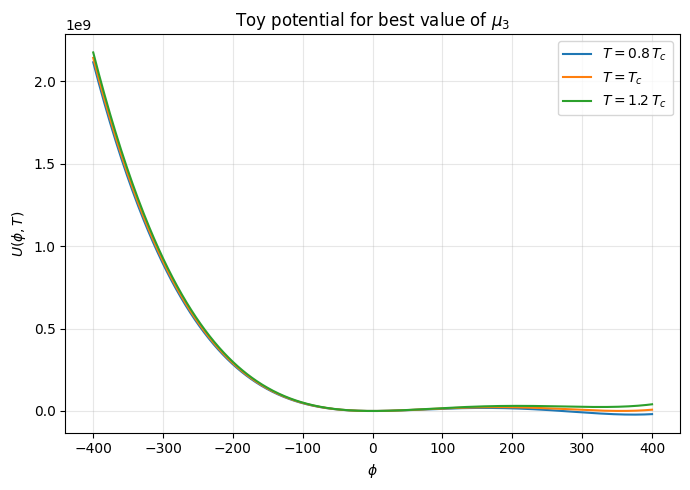

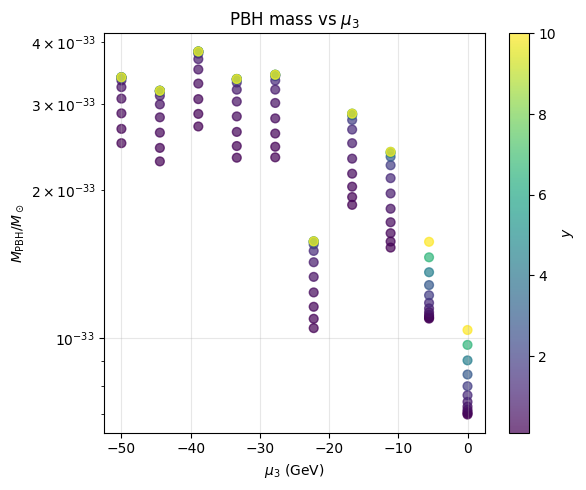

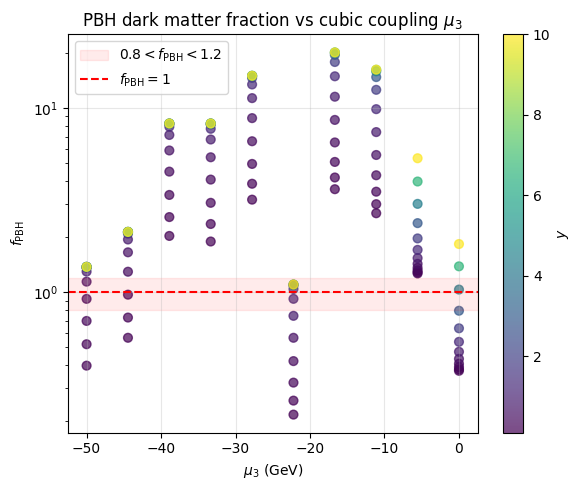

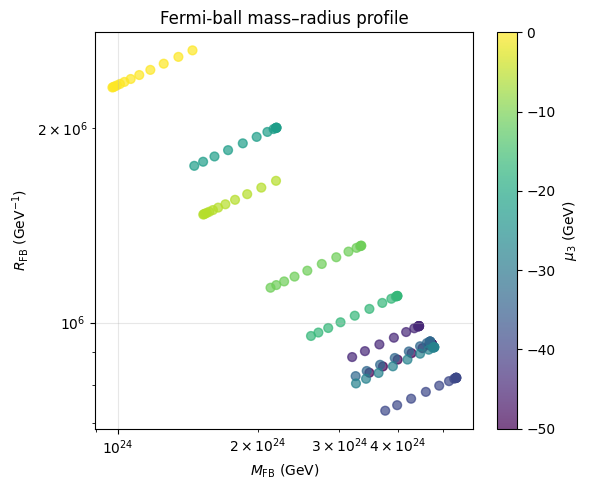

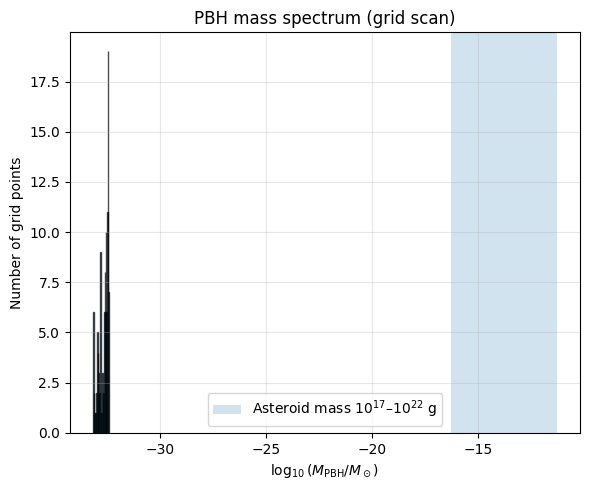

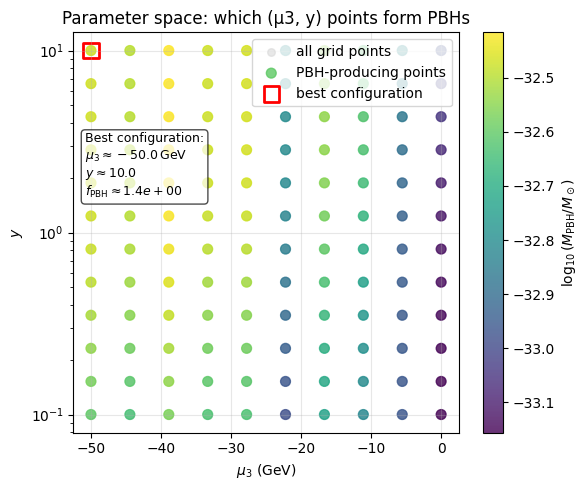

Gaussian Monte Carlo refinement

Refined best configuration:
{'mu3_best': -50.0, 'y_best': 20.92515989645787, 'T_c_best': 45.77757275692146, 'M_PBH_best': 3.3967027474864396e-33, 'f_best': 0.9986365289829823, 'v_best': 355.2178416501902, 'U0_best': 354767.91185832024}


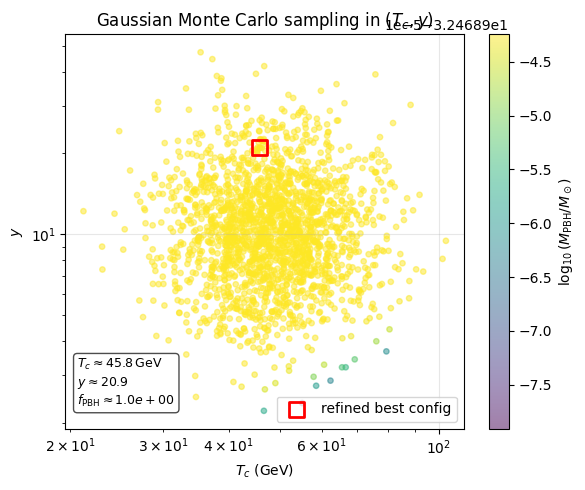

In [ ]:
# Main Driver

if __name__ == "__main__":
  eta_fixed = 1e-25

  # Parameter space
  mu3_values = np.linspace(-50.0, 0.0, 10)
  y_values = np.logspace(-1.0, 1.0, 12)

  print("Running grid simulation")
  results = run_simulation(mu3_values, y_values, eta_fixed)

  best = extract_best_configuration(results)
  print("\nBest grid configuration:")
  print(best)

  mu3_best = best["mu3_best"]
  T_c_best, phi_false_best, phi_true_best, V_false_best, V_true_best = find_critical_temperature_scan(mu3_best)

  dV_best = V_false_best - V_true_best
  U0_best = abs(dV_best)
  if U0_best <= 0.0:
    U0_best = (0.1 * T_c_best)**4

  v_true_best = phi_true_best

  # Store values back into best
  best["T_c_best"] = float(T_c_best)
  best["v_best"] = float(v_true_best)
  best["U0_best"] = float(U0_best)

  print(f"\nFor μ3_best ≈ {mu3_best:.2f} GeV:")
  print(f"  T_c ≈ {T_c_best:.2f} GeV, φ_true(T_c) ≈ {phi_true_best:.2f} GeV")

  # Potential plot at best mu3
  plot_toy_potential(T_c_best, mu3_best)

  # Grid plots
  plot_grid_results(results, best=best)

  # Monte Carlo refinement
  print("Gaussian Monte Carlo refinement")
  best, samples = gaussian_sampling(best, eta_fixed, sigma_logTc=0.1, sigma_logy=0.2, n_samples=2000)

  print("\nRefined best configuration:")
  print(best)

  # MC scatter plot
  fig, ax = plt.subplots(figsize=(6, 5))
  sc = ax.scatter(samples["T_c"], samples["y"], c=np.log10(samples["M_PBH"]), cmap="viridis", s=15, alpha=0.5,)
  ax.set_xscale("log")
  ax.set_yscale("log")
  ax.set_xlabel(r"$T_c$ (GeV)")
  ax.set_ylabel(r"$y$")
  fig.colorbar(sc, ax=ax, label=r"$\log_{10}(M_{\rm PBH} / M_\odot)$")
  ax.set_title("Gaussian Monte Carlo sampling in $(T_c, y)$")
  ax.grid(True, alpha=0.3)

  Tc_best = best["T_c_best"]
  y_best = best["y_best"]
  f_best = best["f_best"]

  ax.scatter(Tc_best, y_best, marker="s", s=120, facecolors="none", edgecolors="red", linewidths=2, label="refined best config",)

  ax.text(0.03, 0.05, rf"$T_c \approx {Tc_best:.1f}\,\mathrm{{GeV}}$" "\n" rf"$y \approx {y_best:.1f}$" "\n" rf"$f_{{\rm PBH}} \approx {f_best:.1e}$", transform=ax.transAxes, fontsize=9, va="bottom", ha="left", bbox=dict(boxstyle="round", facecolor="white", alpha=0.7),)

  ax.legend(loc="lower right")
  plt.tight_layout()
  plt.show()